# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** The Floppas

**Student names & numbers:**
* Miguel Brugge - 102093
* Gabriela Panayotova - 098931
* Svetlozara Kirova - 099153


---

## 0. Iteration setup

**Import libraries**

In [1]:
# CODE CELL: import the necessary libraries for this iteration
import pandas as pd
import matplotlib.pyplot as plt

**Load dataset(s)**

In [2]:
# CODE CELL: import the necessary dataset(s) for this iteration
df = pd.read_csv('data/ships_inventory_iter1.csv')

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

Nebula Brokerage is the largest used spaceship dealer in the galaxy. The company is currently facing a crisis, because their pricing strategy is based on gut feeling and rough averages. The staff uses their intuition and past experience to estimate the prices, rather than looking at actual sales data. This approach is causing a lot of problems within the company, such as rare ships being sometimes sold for far less than they are worth and common freighters sitting unsold for months, because their price is too high. 

Relying on intuition is risky, as it is inconsistent and biased. Different staff might price the same ship differently and as the inventory grows, the guessing will become even less reliable.

Without a data driven baseline, Nebula Brokerage doesn't have any reliable reference price when a new ship arrives. This makes every pricing decision uncertain and increases financial risk.

**Business objective(s)**

The company is losing money because rare ships are being sold for too little, while common freighters are staying on the lot for months because their prices are too high.

To fix this, the main goal is to price ships to the most accurate baseline price to use as a standard reference for incoming ships. That’s why the company needs to base its pricing decisions on real data instead of just guessing or using rough averages.

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

This is a regression modeling task, because the variable (Galactic_Credits) that needs to be predicted is numeric and continuous.

Our goal is to use a simple model, like the mean or median, to set a benchmark for spaceship prices based on different features. So we create a basic reference model that shows what kind of predictions we could make without any complicated methods. This makes us have a starting point to see how well more advanced models perform later. The benchmark should help us understand the data better and give us a clear view to improve on.

**Success criteria**

It is successful when rare ships are no longer sold for too little and common freighters aren’t sitting on the lot for months because of high prices. In other words, when ships are being sold at the most accurate baseline price and can be used as a reliable reference for pricing future ships.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

| Column              | Data type | Interpretation                                                                                                                           |
| ------------------- | --------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| `Ship_ID`            | `int64`   | Unique identifier for the vessel.                              |
| `Galactic_Credits`  | `int64`   |  The price the ship was sold for (target variable).  |
| `Model_Cycle`       | `float64` | The year (cycle) the ship was built. Note: Current year is roughly 3023. |
| `Ship_Manufacturer` | `str`     | The company that built the ship (e.g., Galactic Motors, Kuat Drive Yards).   |
| `Sector`            | `str`     | The region of space where the ship is currently docked.    |

This dataset has five columns: Ship_ID is a unique identifier, Galactic_Credits is the ship’s sale price, and Model_Cycle shows the year built. Ship_Manufacturer and Sector are categorical, indicating the builder and the docking region. It combines numeric and categorical data for analysis.

In [3]:
# CODE CELL: Show basic statistics and information
df.dtypes

Ship_ID                int64
Galactic_Credits       int64
Model_Cycle          float64
Ship_Manufacturer        str
Sector                   str
dtype: object

In [4]:
df.describe()

,Ship_ID,Galactic_Credits,Model_Cycle
count,3.688140e+05,368814.000000,361408.000000
mean,7.311485e+09,19453.536818,7511.264529
std,4.381124e+06,15540.472943,9.078571
min,7.301583e+09,501.000000,7400.000000
25%,7.308105e+09,7950.000000,7508.000000
50%,7.312604e+09,15990.000000,7513.000000
75%,7.315245e+09,27990.000000,7517.000000
max,7.317101e+09,777777.000000,7522.000000


The summary statistics show that the dataset has about 368,000 ships. Ship_ID is just a unique identifier. Galactic_Credits ranges widely, from 501 to 777,777, with a mean around 19,454, indicating large variation in ship prices. Model_Cycle ranges from 7400 to 7522, with most ships built around 7511, suggesting most ships are from similar recent cycles.

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

We observe a significant number of outliers in the Galactic credits data. The diagrams indicate that the distribution is positively skewed. Most ships are priced lower, but a few are very expensive which are pulling the mean up.

We use `uniqueBins` so every different value in the data has its own bar, which makes the graph clear and correct. This is better than picking a fixed number of bins, because guessing can hide how the data really looks.

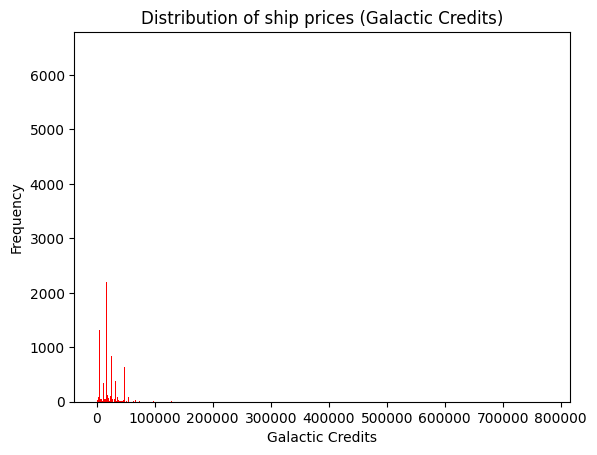

In [5]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)
uniqueBins = df['Galactic_Credits'].nunique()
plt.hist(x=df['Galactic_Credits'], bins=uniqueBins, color='red')
plt.title('Distribution of ship prices (Galactic Credits)')
plt.xlabel('Galactic Credits')
plt.ylabel('Frequency')
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x2203948ae40>,
 'caps': [<matplotlib.lines.Line2D at 0x2203948b0e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2203948acf0>],
 'medians': [<matplotlib.lines.Line2D at 0x2203948b380>],
 'fliers': [<matplotlib.lines.Line2D at 0x2203948b4d0>],
 'means': []}

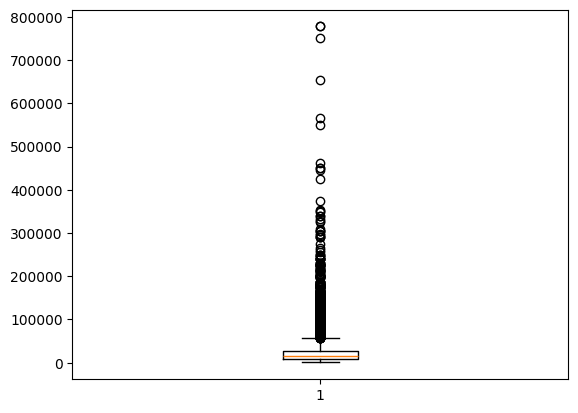

In [6]:
plt.boxplot(df['Galactic_Credits'].dropna())

**Data insights and data quality**
* **Insights:** What are the key trends? What does the distribution look like? What does that mean? 
* **Quality issues:** Document missing values, duplicates, outliers, etc.

**Insights:**
- **Histogram:**  
  Shows that most accounts have low to moderate credits, while a small group has very high credits.

- **Boxplot:**  
  Confirms extreme high-end values (outliers), points beyond the whiskers.

- **Mean > Median** (from `df['Galactic_Credits'].describe()`) confirms the skew.

---

**Quality issues:**
- Missing values: We checked if any values were missing.

- Duplicates: Checked if there were any duplicate values, which we drop for preparing the data.

- High-end outliers: Many accounts have very high credits.

In [7]:
Q1 = df['Galactic_Credits'].quantile(0.25)
Q3 = df['Galactic_Credits'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Galactic_Credits'] < lower_bound) | 
              (df['Galactic_Credits'] > upper_bound)]

print(f"Upper bound for outliers: {upper_bound}")
print(f"Total outliers detected: {len(outliers)}")

Upper bound for outliers: 58050.0
Total outliers detected: 7253


In [8]:
df['Galactic_Credits'].describe()

count    368814.000000
mean      19453.536818
std       15540.472943
min         501.000000
25%        7950.000000
50%       15990.000000
75%       27990.000000
max      777777.000000
Name: Galactic_Credits, dtype: float64

This tells us how many missing values are in each column.

Missing values can mess up calculations or plots, so if there are any, we need to fill them or remove those rows.

In [9]:
df.isnull().sum()

Ship_ID                 0
Galactic_Credits        0
Model_Cycle          7406
Ship_Manufacturer       0
Sector                  0
dtype: int64

This counts exact duplicate rows in the dataset.

Duplicates might be mistakes or repeated entries, so we check them and remove if necessary.

In [10]:
df.duplicated().sum()

np.int64(500)

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

For `Galactic_Credits`, we filled any missing values with the median since it handles extreme values better and avoids bias in the skewed data. We also removed any exact duplicate rows to keep the dataset clean. For outliers, we removed the very high credits above 58,050 using the IQR method, and we left the low end untouched because credits can’t be negative.

In [11]:
# CODE CELL: Data cleaning and preprocessing steps
df['Galactic_Credits'].fillna(df['Galactic_Credits'].median())
df.drop_duplicates()
df_clean = df[df['Galactic_Credits'] <= upper_bound]

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [12]:
# OPTIONAL CODE CELL: Additional preprocessing steps

No additional adjustments were made. The dataset is now clean, consistent, and ready for analysis or modeling.

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

Our team created simple benchmark models to predict `Galactic_Credits`. Since this is a baseline, we did not use any specific features and counted based on overall statistics from the cleaned dataset.

- **Mean model:** Predicts the average Galactic_Credits for every ship.  
- **Median model:** Predicts the median Galactic_Credits for every ship.  

We added two columns to the dataset, `mean_pred` and `median_pred`, which store the predicted values for each ship using the mean and median. These results give us a starting point for future models.

We used both mean and median because the prices vary a lot, and the median gives us a prediction that is less affected by very high prices.

This approach is more direct and provides a clear benchmark for evaluating other models.

In [14]:
# CODE CELL: Model training and setup code
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mean_value = df_clean['Galactic_Credits'].mean()
median_value = df_clean['Galactic_Credits'].median()

df_clean['mean_pred'] = mean_value
df_clean['median_pred'] = median_value

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

In [15]:
# CODE CELL: Model evaluation code
mean_value = df_clean['Galactic_Credits'].mean()
median_value = df_clean['Galactic_Credits'].median()

df_clean['mean_pred'] = mean_value
df_clean['median_pred'] = median_value

mae_mean = mean_absolute_error(df_clean['Galactic_Credits'], df_clean['mean_pred'])
rmse_mean = root_mean_squared_error(df_clean['Galactic_Credits'], df_clean['mean_pred'])

mae_median = mean_absolute_error(df_clean['Galactic_Credits'], df_clean['median_pred'])
rmse_median = root_mean_squared_error(df_clean['Galactic_Credits'], df_clean['median_pred'])

print("Mean model: MAE =", mae_mean, "RMSE =", rmse_mean)
print("Median model: MAE =", mae_median, "RMSE =", rmse_median)

Mean model: MAE = 10500.163286843674 RMSE = 12605.869212010657
Median model: MAE = 10295.152154131669 RMSE = 12896.43264177865


In [16]:
df_clean.head()

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,mean_pred,median_pred
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,18312.138184,15590.0
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,18312.138184,15590.0
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,18312.138184,15590.0
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,18312.138184,15590.0
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,18312.138184,15590.0


---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*What is the difference between the metrics? What does this mean? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What did you learn? What are the limitations of this current model?*

### Why we chose the median
We use the median because the data is skewed, meaning there are some very large or very small values. The mean gets pulled toward these extreme values, but the median stays in the middle. Because of this, the median gives a more fair and stable value for the data, which is why it works better here.

### Difference between the metrics
MAE shows the average size of the errors, so it tells us how far off the model is in a simple and easy way. RMSE also measures error, but it punishes big mistakes more, meaning large errors affect it more than small ones. This is why RMSE is usually higher and helps show if the model makes some very large errors.

### Reflection on the goal set in the Business understanding
Using the median gave us a simple way to predict spaceship prices and set a clear starting point. The errors we saw (MAE for average mistakes, RMSE for big ones) make sense for this basic model. Our goal was just to have a baseline to compare against later models, and it does that well.

### Our learnings
From this first iteration, we learned that extreme prices make averages unreliable and that a simple median can give a stable starting point. MAE and RMSE helped us see where predictions were off. Most of all, starting with a basic model showed us how much we can improve when we include more information about the ships.

### Limitations of this current model
This model does not use any specific features of the spaceship (manifacturer, model cycle, sector). Its goal is just serve as a starting point. To make the more accurate price predictions, we would need to include this extra information.

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

#### Contributions
We as a team sat down a total of three times to make this notebook together. We put one laptop on the big screen and worked together to get to the solutions. For this reason, we all have an equal contribution to the project.

| Student name | Personal lessons learned |
| :--- | :--- |
| Gabriela | *Jupyter notebooks, working with a venv, pandas🐼, reading and cleaning data, math, creating and evaluating benchmark models, Understanding skewed data, Adding new columns to a DataFrame for predictions* |
| Miguel | *Exploring data in Jupyter notebooks, setting up and using a venv, manipulating data with pandas, data cleaning and preparation, applying basic mathematical operations, developing and testing benchmark models, understanding when data is skewed, adding prediction columns to the DataFrame* |
| Svetlozara | *Python, Jupyter notebooks, managing a virtual environment, working with pandas, importing and cleaning datasets, performing calculations, building and assessing simple benchmark models, recognizing and handling skewed data, creating new DataFrame columns for predictions* |

In [17]:
df_clean.to_csv("ships_inventory_iter1_out.csv", index=False)